# Exploratory Data Analysis - Price Forecasting with Forecast Features

**Dataset**: `price_forecasting_dataset_with_forecasts.csv`  
**Period**: 2023-01-09 to 2024-12-30  
**Samples**: 17,124 hourly observations  
**Features**: 53 (historical + forecasts + calendar)  

---

## Objective

This notebook analyzes the complete price forecasting dataset including:
1. **Historical features** (price/load lags, rolling stats)
2. **Weather forecasts** (temperature, wind, solar radiation at t+24h)
3. **Load forecasts** (electricity demand at t+24h)
4. **Renewable forecasts** (wind/solar production at t+24h)
5. **Calendar features** (cyclical time encodings)

---

## Table of Contents

1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis (Price)
4. Weather Forecast Features
5. Load & Renewable Forecasts
6. Net Load Analysis
7. Historical Features (Lags & Rolling Stats)
8. Correlation Analysis
9. Temporal Patterns
10. Feature Importance Preview
11. Data Quality Checks
12. Summary & Key Insights

## 1. Setup & Data Loading

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from scipy import stats
from scipy.stats import spearmanr, pearsonr

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

# Paths
project_root = Path.cwd().parent.parent
data_file = project_root / 'data' / 'processed' / 'price_forecasting_dataset_with_forecasts.csv'
features_file = project_root / 'data' / 'processed' / 'price_forecasting_dataset_with_forecasts_features.txt'

print("✅ Setup complete")
print(f"📂 Data file: {data_file}")
print(f"📂 Features file: {features_file}")

✅ Setup complete
📂 Data file: c:\Users\arnov\Desktop\energy-demand-forecast\data\processed\price_forecasting_dataset_with_forecasts.csv
📂 Features file: c:\Users\arnov\Desktop\energy-demand-forecast\data\processed\price_forecasting_dataset_with_forecasts_features.txt


In [2]:
# Load dataset
df = pd.read_csv(data_file)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])
df = df.sort_values('datetime_hour').reset_index(drop=True)

# Load feature list
with open(features_file, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"✅ Dataset loaded")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df['datetime_hour'].min()} to {df['datetime_hour'].max()}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: price (EUR/MWh)")

✅ Dataset loaded
   Shape: (17124, 63)
   Date range: 2023-01-09 04:00:00 to 2024-12-30 23:00:00
   Features: 53
   Target: price (EUR/MWh)


## 2. Dataset Overview

In [3]:
# Display first rows
display_cols = ['datetime_hour', 'price', 'load_forecast', 'temp_forecast', 
                'net_load_forecast_mw', 'renewable_production_forecast_mw']
print("\n📊 Sample data:")
df[display_cols].head(10)


📊 Sample data:


,datetime_hour,price,load_forecast,temp_forecast,net_load_forecast_mw,renewable_production_forecast_mw
0,2023-01-09 04:00:00,43.99,37056.854278,3.163930,16156.854278,20900.000000
1,2023-01-09 05:00:00,85.26,39937.344182,2.870125,39937.344182,0.000000
2,2023-01-09 06:00:00,160.32,43689.924169,2.759537,41782.500285,1907.423884
3,2023-01-09 07:00:00,180.00,48527.320318,3.793648,27627.320318,20900.000000
4,2023-01-09 08:00:00,177.27,51355.895702,4.373347,51355.895702,0.000000
5,2023-01-09 09:00:00,159.56,52896.922262,4.993431,31996.922262,20900.000000
6,2023-01-09 10:00:00,161.21,55200.008801,6.252727,55200.008801,0.000000
7,2023-01-09 11:00:00,140.56,55900.785860,5.875752,55900.785860,0.000000
8,2023-01-09 12:00:00,135.87,53872.307626,8.225476,53872.307626,0.000000
9,2023-01-09 13:00:00,136.58,53251.718569,7.885869,52414.312773,837.405796


In [4]:
# Basic statistics
print("\n📈 Summary statistics for key variables:\n")
key_vars = ['price', 'load_forecast', 'temp_forecast', 'wind_production_forecast_mw', 
            'solar_production_forecast_mw', 'net_load_forecast_mw']
df[key_vars].describe().round(2)


📈 Summary statistics for key variables:



,price,load_forecast,temp_forecast,wind_production_forecast_mw,solar_production_forecast_mw,net_load_forecast_mw
count,17124.00,17124.00,17124.00,17124.00,17124.00,17124.00
mean,77.65,45342.76,12.86,10573.68,1970.38,32798.71
std,46.95,7573.89,6.75,9944.15,2921.02,12487.78
min,-134.94,26190.65,-7.97,0.00,0.00,4742.14
25%,44.31,39326.36,8.36,0.00,0.00,22586.71
50%,80.40,46825.82,12.44,10346.07,76.52,33165.70
75%,107.01,51153.48,17.55,20900.00,3122.03,42685.60
max,284.21,63508.08,35.41,20900.00,15166.39,62524.08


In [5]:
# Check for missing values
print("\n🔍 Missing values check:\n")
missing = df[feature_cols + ['price']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values!")


🔍 Missing values check:

✅ No missing values!


In [6]:
# Categorize features
calendar_features = [c for c in feature_cols if any(x in c for x in 
    ['hour', 'day', 'month', 'week', 'year', 'sin', 'cos', 'weekend', 'peak', 'winter', 'summer'])]

lag_features = [c for c in feature_cols if 'lag' in c or 'roll' in c]

forecast_weather = [c for c in feature_cols if 'forecast' in c and 
    any(x in c for x in ['temp', 'wind', 'solar', 'humidity', 'precipitation', 'cloudcover'])]

forecast_load = [c for c in feature_cols if 'load_forecast' in c]

forecast_renewable = [c for c in feature_cols if any(x in c for x in 
    ['renewable', 'wind_production', 'solar_production', 'net_load', 'capacity_factor', 
     'penetration', 'coverage', 'curtailment', 'residual'])]

print("\n📦 Feature categories:")
print(f"   Calendar features: {len(calendar_features)}")
print(f"   Historical lags & rolling stats: {len(lag_features)}")
print(f"   Weather forecasts: {len(forecast_weather)}")
print(f"   Load forecast: {len(forecast_load)}")
print(f"   Renewable forecasts: {len(forecast_renewable)}")
print(f"   " + "="*50)
print(f"   Total features: {len(feature_cols)}")


📦 Feature categories:
   Calendar features: 17
   Historical lags & rolling stats: 16
   Weather forecasts: 9
   Load forecast: 2
   Renewable forecasts: 10
   Total features: 53


## 3. Target Variable Analysis (Price)

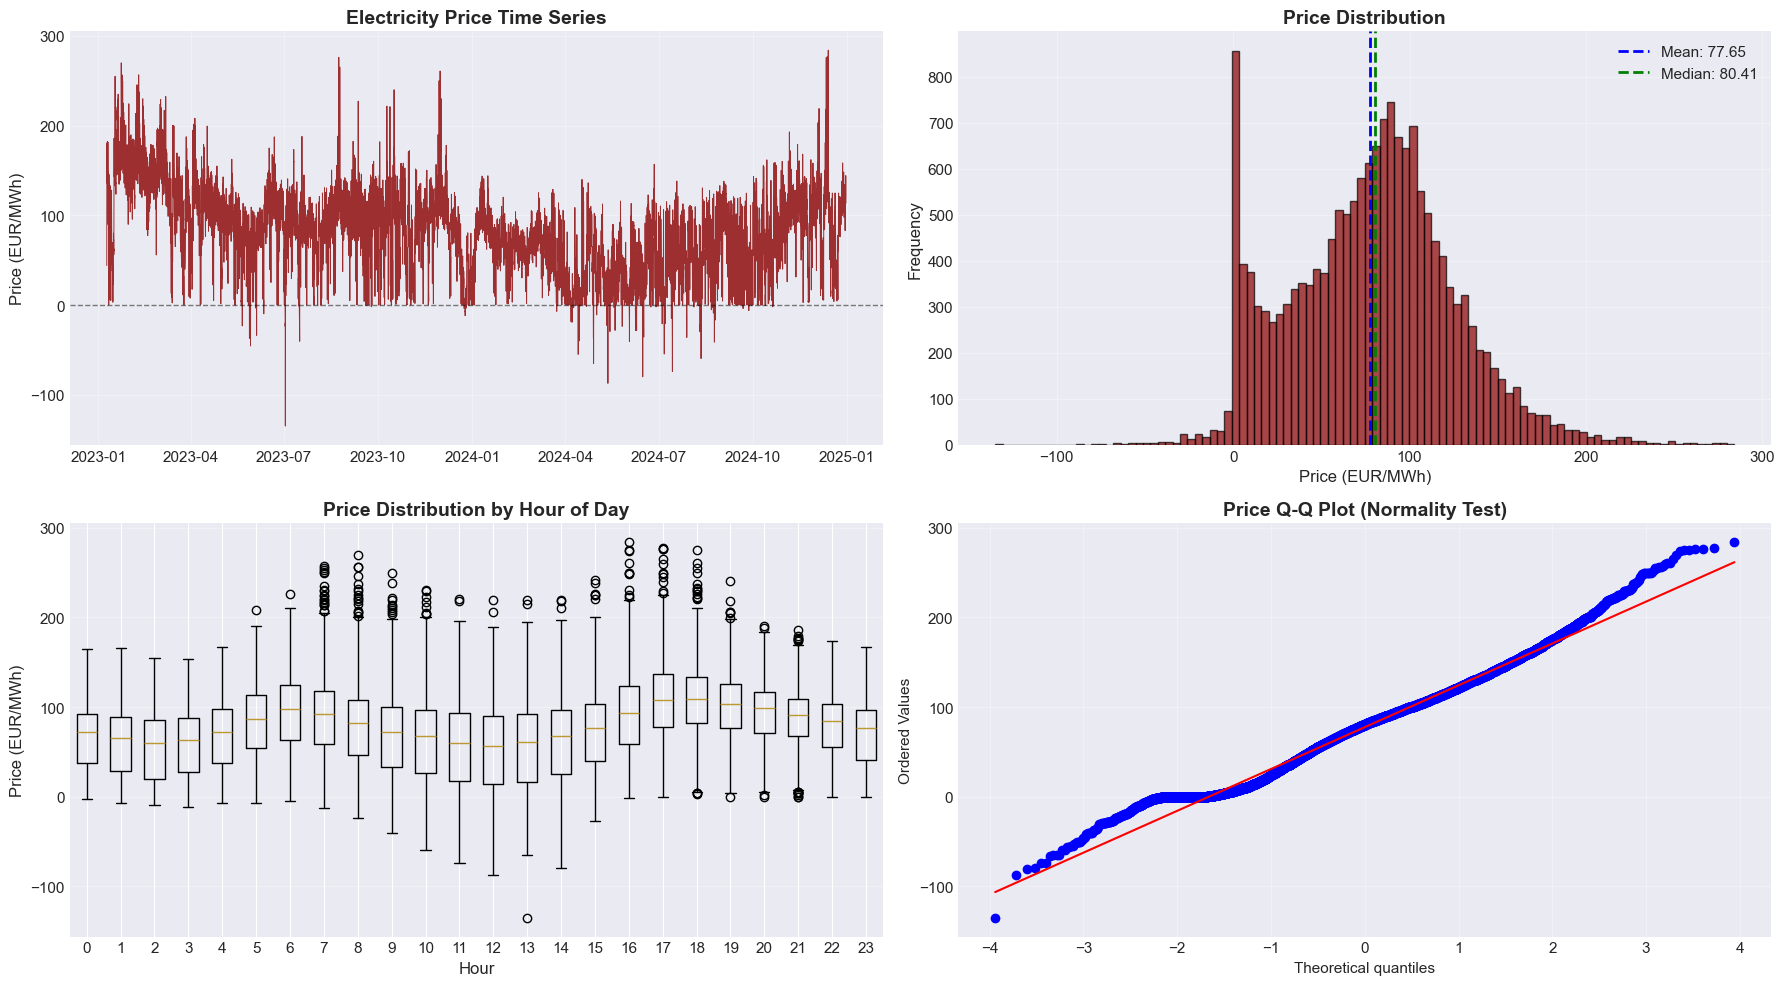


📊 Price Statistics:
   Mean: 77.65 EUR/MWh
   Median: 80.41 EUR/MWh
   Std Dev: 46.95 EUR/MWh
   Min: -134.94 EUR/MWh
   Max: 284.21 EUR/MWh
   Skewness: 0.191
   Kurtosis: 0.117

   Negative prices: 472 (2.76%)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Time series
axes[0, 0].plot(df['datetime_hour'], df['price'], linewidth=0.7, alpha=0.8, color='darkred')
axes[0, 0].set_title('Electricity Price Time Series', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Distribution
axes[0, 1].hist(df['price'], bins=100, edgecolor='black', alpha=0.7, color='darkred')
axes[0, 1].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price (EUR/MWh)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].axvline(df['price'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {df['price'].mean():.2f}")
axes[0, 1].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['price'].median():.2f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot by hour
hour_price = df.groupby(df['datetime_hour'].dt.hour)['price'].apply(list)
axes[1, 0].boxplot(hour_price, positions=range(24), widths=0.6)
axes[1, 0].set_title('Price Distribution by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour', fontsize=12)
axes[1, 0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Q-Q plot
stats.probplot(df['price'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Price Q-Q Plot (Normality Test)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Price statistics
print("\n📊 Price Statistics:")
print(f"   Mean: {df['price'].mean():.2f} EUR/MWh")
print(f"   Median: {df['price'].median():.2f} EUR/MWh")
print(f"   Std Dev: {df['price'].std():.2f} EUR/MWh")
print(f"   Min: {df['price'].min():.2f} EUR/MWh")
print(f"   Max: {df['price'].max():.2f} EUR/MWh")
print(f"   Skewness: {df['price'].skew():.3f}")
print(f"   Kurtosis: {df['price'].kurtosis():.3f}")
print(f"\n   Negative prices: {(df['price'] < 0).sum()} ({(df['price'] < 0).sum() / len(df) * 100:.2f}%)")

## 4. Weather Forecast Features

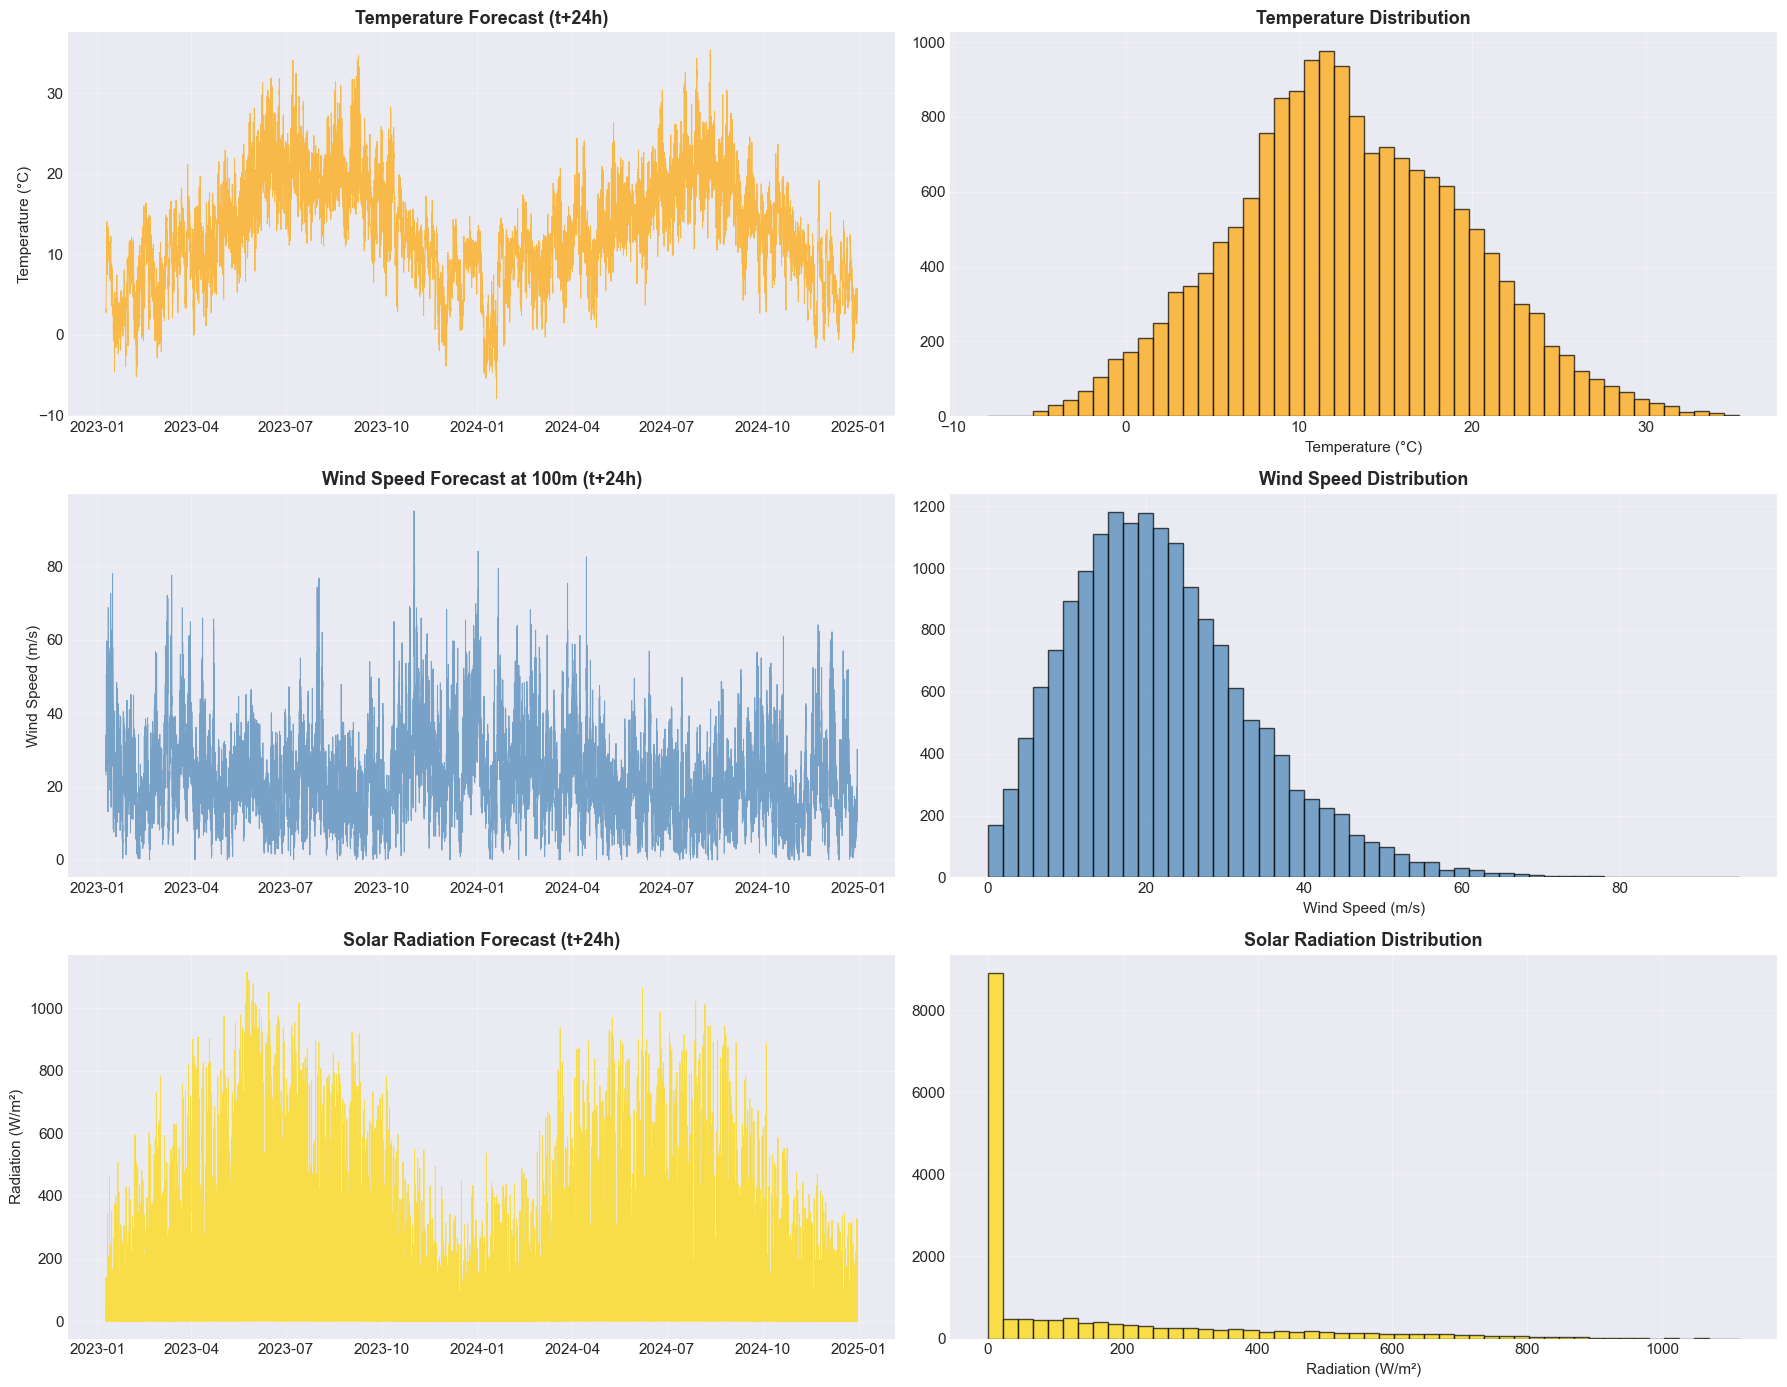


🌤️ Weather Forecast Statistics:
   Temperature: 12.9°C ± 6.7°C
   Wind Speed (100m): 22.1 m/s ± 11.8 m/s
   Solar Radiation: 145 W/m² ± 215 W/m²


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Temperature forecast
axes[0, 0].plot(df['datetime_hour'], df['temp_forecast'], linewidth=0.7, alpha=0.7, color='orange')
axes[0, 0].set_title('Temperature Forecast (t+24h)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Temperature distribution
axes[0, 1].hist(df['temp_forecast'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Temperature Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Temperature (°C)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Wind speed forecast
axes[1, 0].plot(df['datetime_hour'], df['wind100m_forecast'], linewidth=0.7, alpha=0.7, color='steelblue')
axes[1, 0].set_title('Wind Speed Forecast at 100m (t+24h)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Wind Speed (m/s)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Wind distribution
axes[1, 1].hist(df['wind100m_forecast'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Wind Speed Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Wind Speed (m/s)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Solar radiation forecast
axes[2, 0].plot(df['datetime_hour'], df['solar_radiation_forecast'], linewidth=0.7, alpha=0.7, color='gold')
axes[2, 0].set_title('Solar Radiation Forecast (t+24h)', fontsize=13, fontweight='bold')
axes[2, 0].set_ylabel('Radiation (W/m²)', fontsize=11)
axes[2, 0].grid(True, alpha=0.3)

# Solar distribution
axes[2, 1].hist(df['solar_radiation_forecast'], bins=50, edgecolor='black', alpha=0.7, color='gold')
axes[2, 1].set_title('Solar Radiation Distribution', fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel('Radiation (W/m²)', fontsize=11)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🌤️ Weather Forecast Statistics:")
print(f"   Temperature: {df['temp_forecast'].mean():.1f}°C ± {df['temp_forecast'].std():.1f}°C")
print(f"   Wind Speed (100m): {df['wind100m_forecast'].mean():.1f} m/s ± {df['wind100m_forecast'].std():.1f} m/s")
print(f"   Solar Radiation: {df['solar_radiation_forecast'].mean():.0f} W/m² ± {df['solar_radiation_forecast'].std():.0f} W/m²")

## 5. Load & Renewable Forecasts

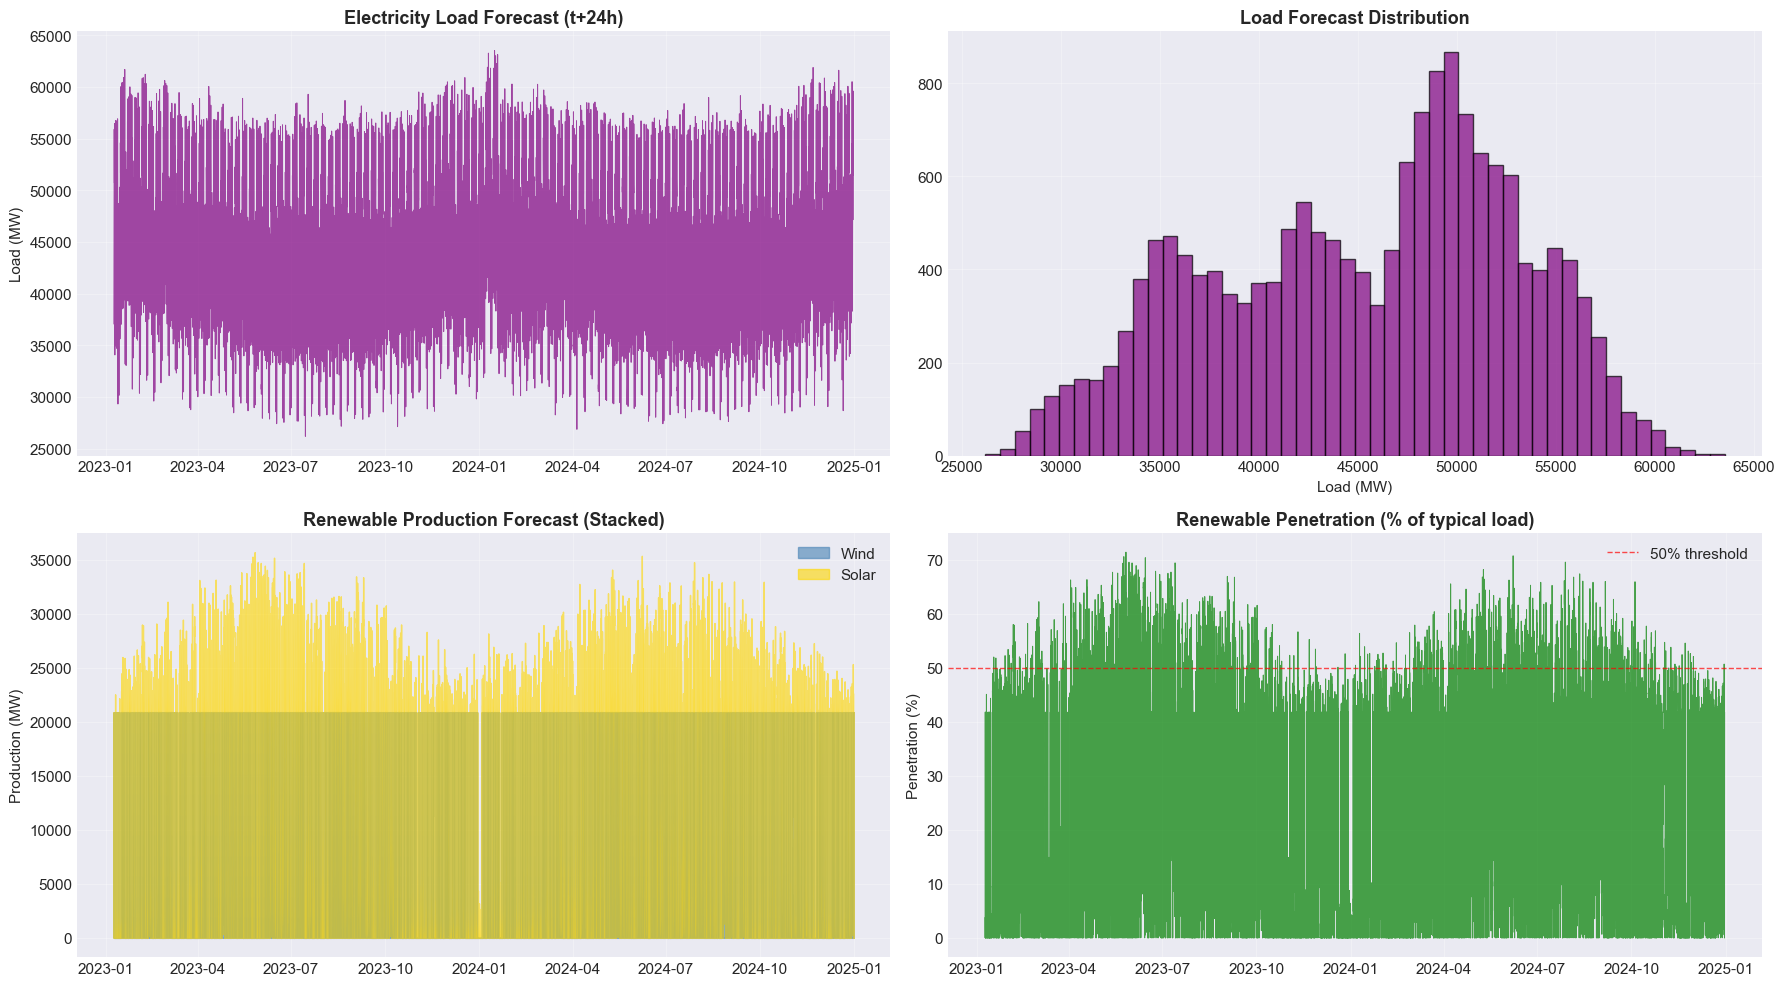


⚡ Load & Renewable Statistics:
   Load forecast: 45343 MW ± 7574 MW
   Wind production: 10574 MW (48.1% capacity factor)
   Solar production: 1970 MW (11.6% capacity factor)
   Total renewable: 12544 MW
   Renewable penetration: 25.1%


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Load forecast
axes[0, 0].plot(df['datetime_hour'], df['load_forecast'], linewidth=0.7, alpha=0.7, color='purple')
axes[0, 0].set_title('Electricity Load Forecast (t+24h)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Load (MW)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Load distribution
axes[0, 1].hist(df['load_forecast'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].set_title('Load Forecast Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Load (MW)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Renewable production stacked
axes[1, 0].fill_between(df['datetime_hour'], 0, df['wind_production_forecast_mw'], 
                         alpha=0.6, label='Wind', color='steelblue')
axes[1, 0].fill_between(df['datetime_hour'], df['wind_production_forecast_mw'], 
                         df['wind_production_forecast_mw'] + df['solar_production_forecast_mw'],
                         alpha=0.6, label='Solar', color='gold')
axes[1, 0].set_title('Renewable Production Forecast (Stacked)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Production (MW)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Renewable penetration
axes[1, 1].plot(df['datetime_hour'], df['renewable_penetration_pct'], linewidth=0.7, alpha=0.7, color='green')
axes[1, 1].set_title('Renewable Penetration (% of typical load)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Penetration (%)', fontsize=11)
axes[1, 1].axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% threshold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚡ Load & Renewable Statistics:")
print(f"   Load forecast: {df['load_forecast'].mean():.0f} MW ± {df['load_forecast'].std():.0f} MW")
print(f"   Wind production: {df['wind_production_forecast_mw'].mean():.0f} MW ({df['wind_capacity_factor'].mean()*100:.1f}% capacity factor)")
print(f"   Solar production: {df['solar_production_forecast_mw'].mean():.0f} MW ({df['solar_capacity_factor'].mean()*100:.1f}% capacity factor)")
print(f"   Total renewable: {df['renewable_production_forecast_mw'].mean():.0f} MW")
print(f"   Renewable penetration: {df['renewable_penetration_pct'].mean():.1f}%")

## 6. Net Load Analysis

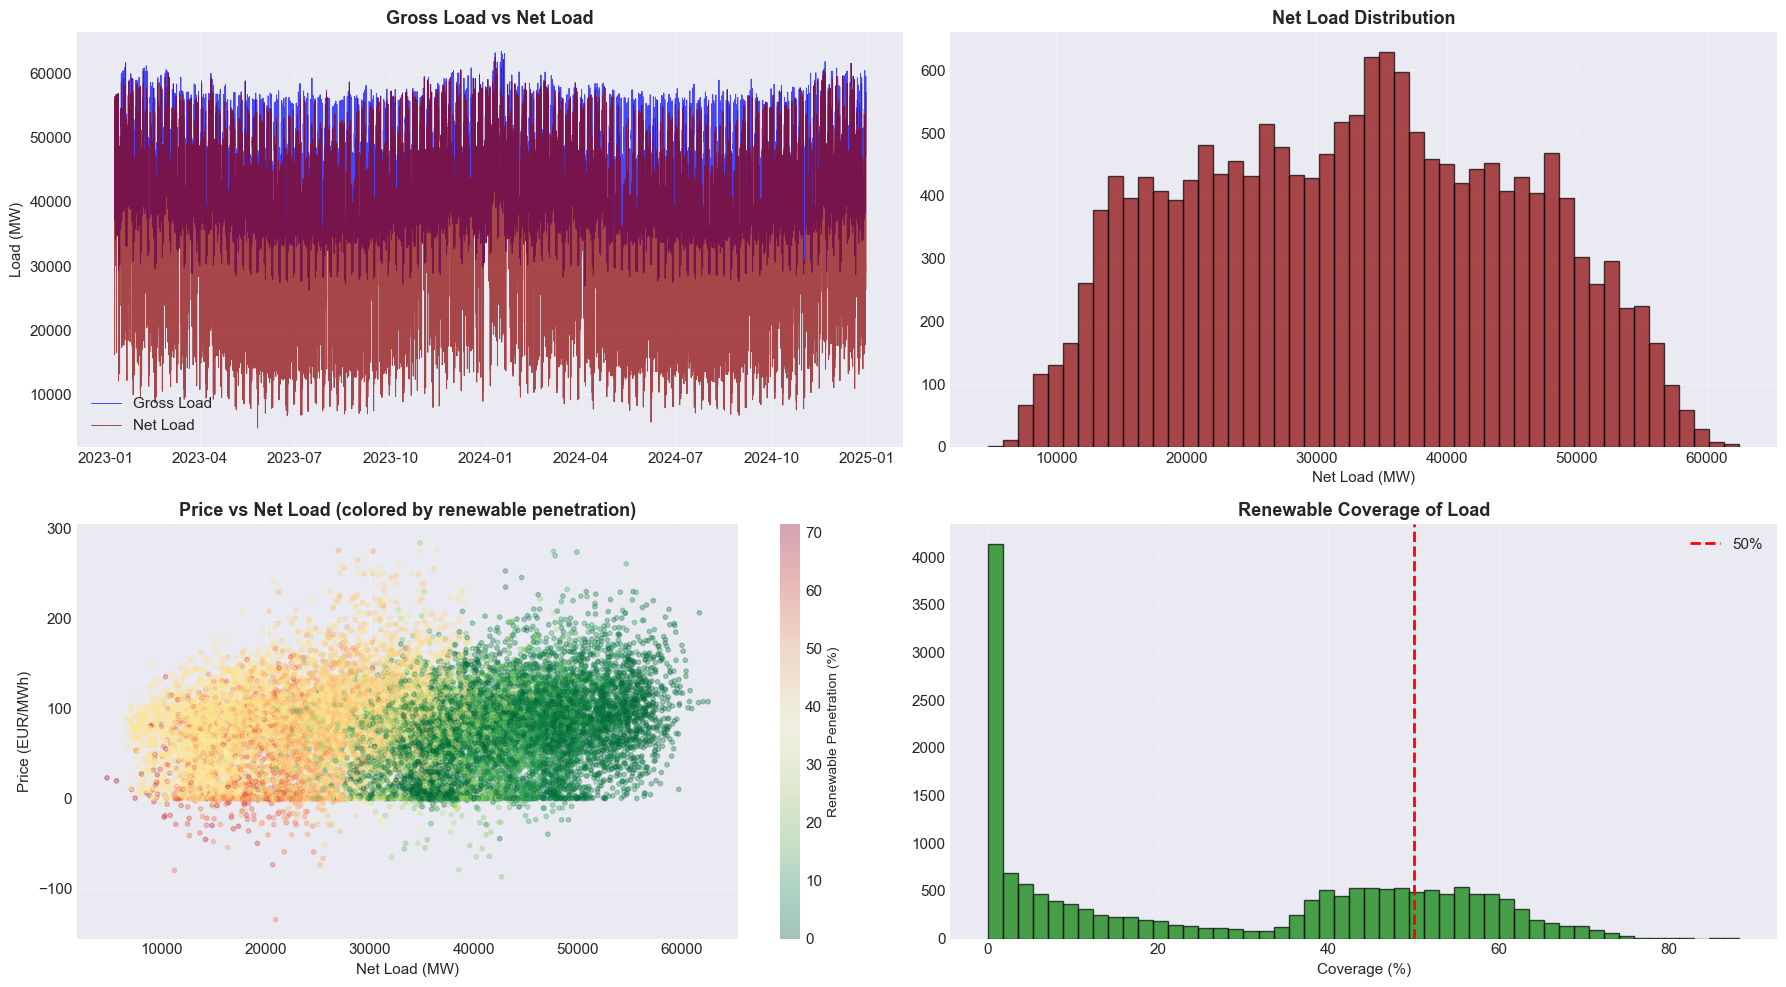


🔋 Net Load Statistics:
   Mean net load: 32799 MW
   Renewable coverage: 28.2% (mean)
   Hours with >50% renewable: 4323 (25.2%)
   Correlation price-netload: 0.151


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Net load vs gross load
axes[0, 0].plot(df['datetime_hour'], df['load_forecast'], linewidth=0.7, alpha=0.7, label='Gross Load', color='blue')
axes[0, 0].plot(df['datetime_hour'], df['net_load_forecast_mw'], linewidth=0.7, alpha=0.7, label='Net Load', color='darkred')
axes[0, 0].set_title('Gross Load vs Net Load', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Load (MW)', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Net load distribution
axes[0, 1].hist(df['net_load_forecast_mw'], bins=50, edgecolor='black', alpha=0.7, color='darkred')
axes[0, 1].set_title('Net Load Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Net Load (MW)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Price vs Net Load scatter
axes[1, 0].scatter(df['net_load_forecast_mw'], df['price'], alpha=0.3, s=10, c=df['renewable_penetration_pct'], cmap='RdYlGn_r')
axes[1, 0].set_title('Price vs Net Load (colored by renewable penetration)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Net Load (MW)', fontsize=11)
axes[1, 0].set_ylabel('Price (EUR/MWh)', fontsize=11)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Renewable Penetration (%)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Renewable coverage
axes[1, 1].hist(df['renewable_coverage_pct'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Renewable Coverage of Load', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Coverage (%)', fontsize=11)
axes[1, 1].axvline(50, color='red', linestyle='--', linewidth=2, label='50%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔋 Net Load Statistics:")
print(f"   Mean net load: {df['net_load_forecast_mw'].mean():.0f} MW")
print(f"   Renewable coverage: {df['renewable_coverage_pct'].mean():.1f}% (mean)")
print(f"   Hours with >50% renewable: {(df['renewable_coverage_pct'] > 50).sum()} ({(df['renewable_coverage_pct'] > 50).sum() / len(df) * 100:.1f}%)")
print(f"   Correlation price-netload: {df[['price', 'net_load_forecast_mw']].corr().iloc[0, 1]:.3f}")

## 7. Historical Features (Lags & Rolling Stats)

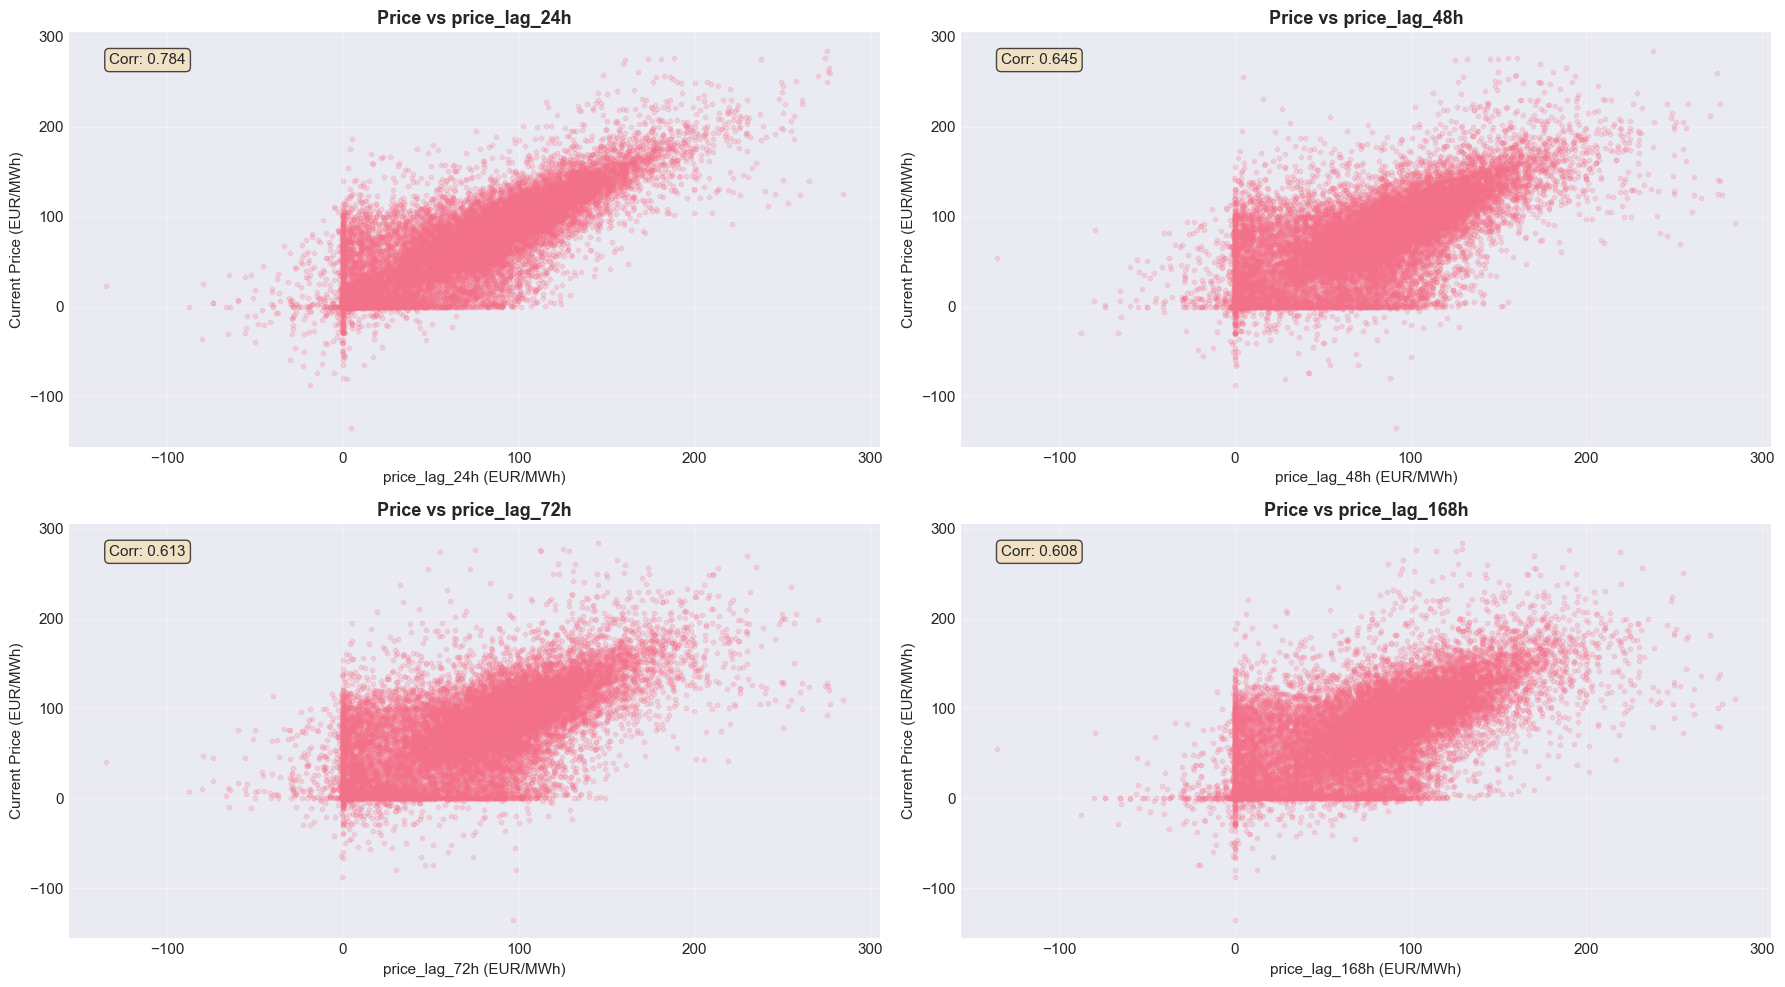


📈 Lag Feature Correlations with Price:
   price_lag_24h: 0.7838
   price_lag_48h: 0.6452
   price_lag_72h: 0.6132
   price_lag_168h: 0.6075


In [11]:
# Plot lag features
lag_cols = ['price_lag_24h', 'price_lag_48h', 'price_lag_72h', 'price_lag_168h']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, lag_col in enumerate(lag_cols):
    ax = axes[i // 2, i % 2]
    ax.scatter(df[lag_col], df['price'], alpha=0.2, s=10)
    ax.set_title(f'Price vs {lag_col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{lag_col} (EUR/MWh)', fontsize=11)
    ax.set_ylabel('Current Price (EUR/MWh)', fontsize=11)
    
    # Add correlation
    corr = df[[lag_col, 'price']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'Corr: {corr:.3f}', transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Lag Feature Correlations with Price:")
for lag_col in lag_cols:
    corr = df[[lag_col, 'price']].corr().iloc[0, 1]
    print(f"   {lag_col}: {corr:.4f}")

## 8. Correlation Analysis

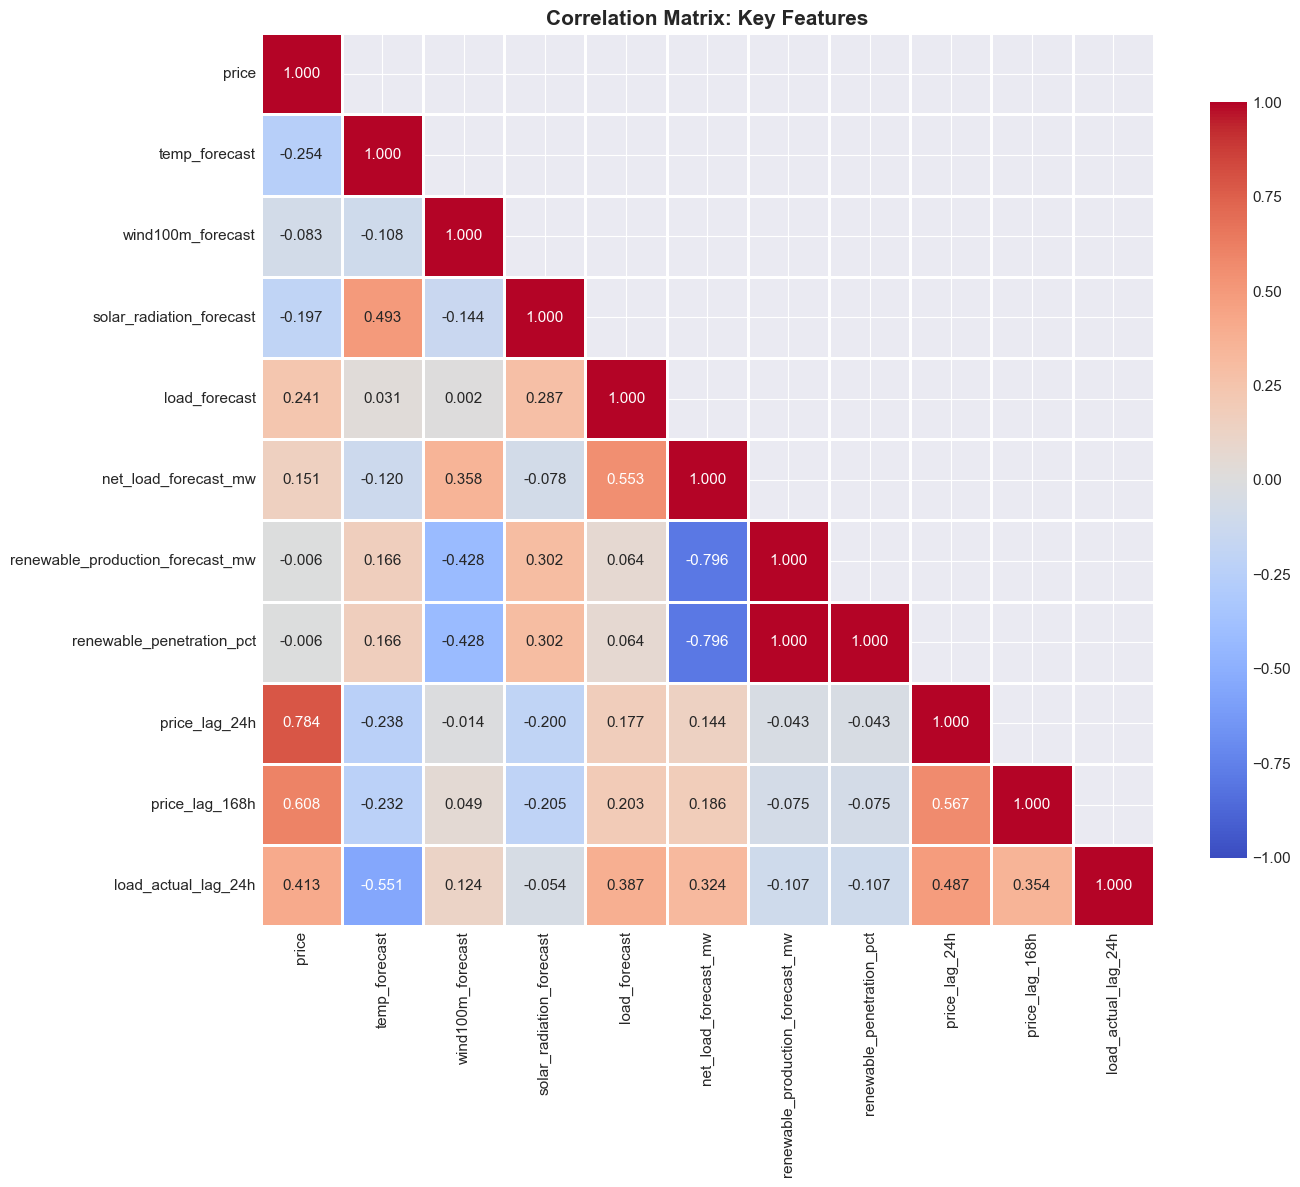


🔝 Top 15 Features Correlated with Price:

price_lag_24h                 0.783845
price_lag_48h                 0.645217
price_roll_mean_168h          0.636502
price_roll_mean_24h           0.636422
price_lag_72h                 0.613170
price_lag_168h                0.607513
load_actual_lag_24h           0.412647
load_actual_roll_mean_24h     0.364947
load_actual_lag_168h          0.349113
load_actual_roll_mean_168h    0.337599
load_actual_lag_48h           0.331831
load_actual_lag_72h           0.301574
load_actual_roll_std_168h     0.276200
month_cos                     0.269444
load_forecast                 0.240871
Name: price, dtype: float64

⬇️ Bottom 15 Features (Negative Correlation):

month                          -0.071841
week_of_year                   -0.073923
wind100m_forecast              -0.083440
is_night                       -0.099254
wind10m_forecast               -0.115051
is_summer                      -0.134658
hour_sin                       -0.147765
day_of_we

In [12]:
# Select key features for correlation matrix
key_features = [
    'price',
    'temp_forecast',
    'wind100m_forecast',
    'solar_radiation_forecast',
    'load_forecast',
    'net_load_forecast_mw',
    'renewable_production_forecast_mw',
    'renewable_penetration_pct',
    'price_lag_24h',
    'price_lag_168h',
    'load_actual_lag_24h',
]

# Compute correlation matrix
corr_matrix = df[key_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Key Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with price
price_corr = df[feature_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
print("\n🔝 Top 15 Features Correlated with Price:\n")
print(price_corr.head(15))

print("\n⬇️ Bottom 15 Features (Negative Correlation):\n")
print(price_corr.tail(15))

## 9. Temporal Patterns

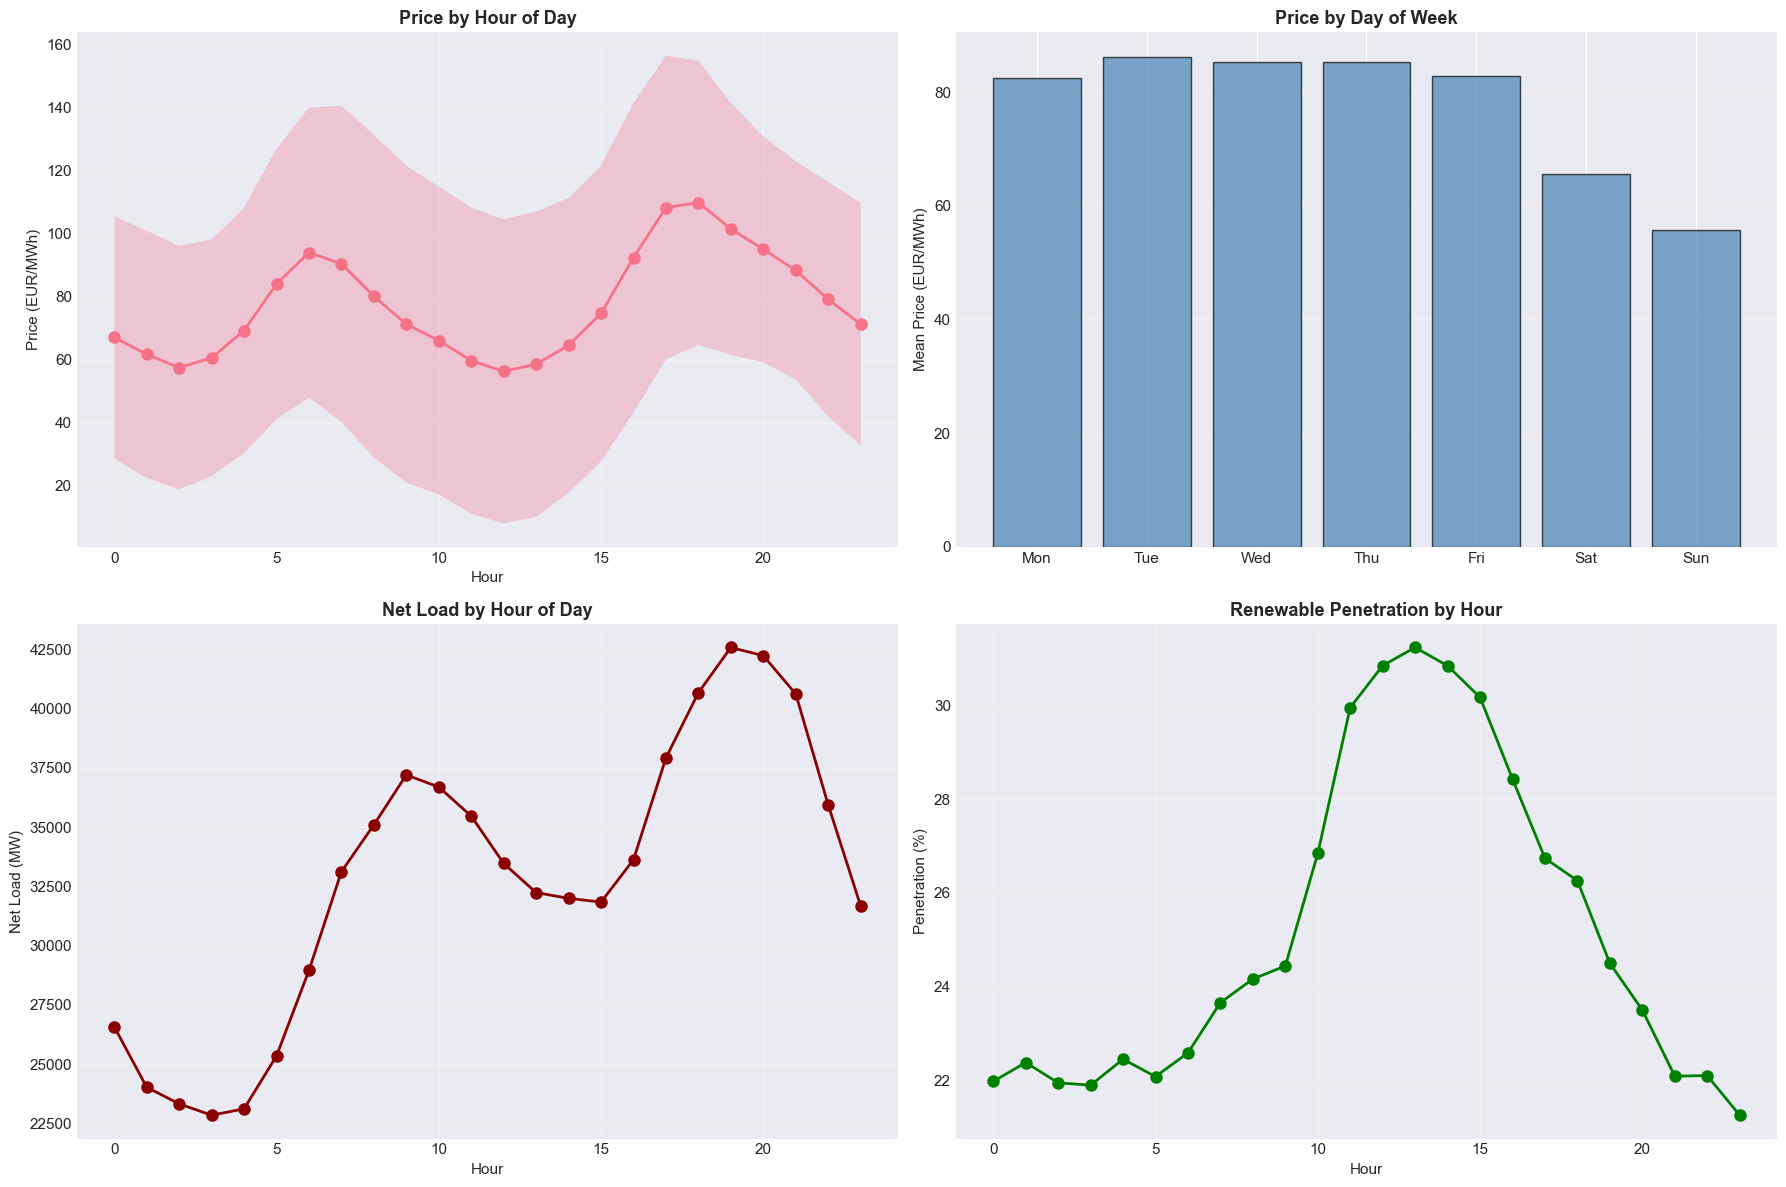

In [13]:
# Add temporal features for analysis
df['hour_of_day'] = df['datetime_hour'].dt.hour
df['day_of_week_name'] = df['datetime_hour'].dt.day_name()
df['month_name'] = df['datetime_hour'].dt.month_name()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Price by hour
hourly_price = df.groupby('hour_of_day')['price'].agg(['mean', 'std'])
axes[0, 0].plot(hourly_price.index, hourly_price['mean'], marker='o', linewidth=2, markersize=8)
axes[0, 0].fill_between(hourly_price.index, 
                         hourly_price['mean'] - hourly_price['std'],
                         hourly_price['mean'] + hourly_price['std'],
                         alpha=0.3)
axes[0, 0].set_title('Price by Hour of Day', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Hour', fontsize=11)
axes[0, 0].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Price by day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_price = df.groupby('day_of_week_name')['price'].mean().reindex(dow_order)
axes[0, 1].bar(range(7), dow_price.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].set_title('Price by Day of Week', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Mean Price (EUR/MWh)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Net load by hour
hourly_netload = df.groupby('hour_of_day')['net_load_forecast_mw'].mean()
axes[1, 0].plot(hourly_netload.index, hourly_netload.values, marker='o', linewidth=2, markersize=8, color='darkred')
axes[1, 0].set_title('Net Load by Hour of Day', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Hour', fontsize=11)
axes[1, 0].set_ylabel('Net Load (MW)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Renewable penetration by hour
hourly_renewable = df.groupby('hour_of_day')['renewable_penetration_pct'].mean()
axes[1, 1].plot(hourly_renewable.index, hourly_renewable.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1, 1].set_title('Renewable Penetration by Hour', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Hour', fontsize=11)
axes[1, 1].set_ylabel('Penetration (%)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Feature Importance Preview (Quick RF)

Training quick Random Forest for feature importance...


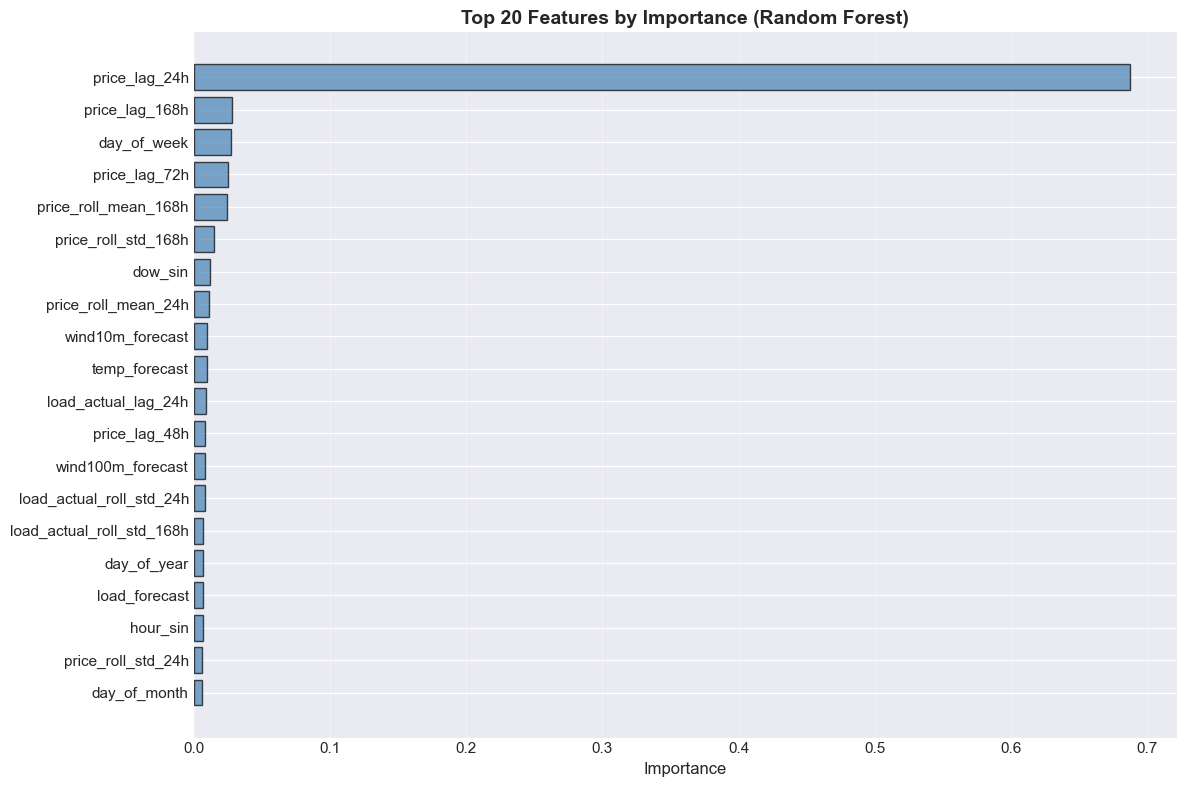


🌟 Top 20 Features:

                  feature  importance
            price_lag_24h    0.687349
           price_lag_168h    0.028090
              day_of_week    0.027226
            price_lag_72h    0.025120
     price_roll_mean_168h    0.024670
      price_roll_std_168h    0.015024
                  dow_sin    0.011930
      price_roll_mean_24h    0.011265
         wind10m_forecast    0.009717
            temp_forecast    0.009658
      load_actual_lag_24h    0.008824
            price_lag_48h    0.008472
        wind100m_forecast    0.008037
 load_actual_roll_std_24h    0.007907
load_actual_roll_std_168h    0.007064
              day_of_year    0.007042
            load_forecast    0.007039
                 hour_sin    0.006569
       price_roll_std_24h    0.006243
             day_of_month    0.006164


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Quick feature importance with small RF
print("Training quick Random Forest for feature importance...")

# Sample data for speed
sample_size = min(5000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

X_sample = df_sample[feature_cols]
y_sample = df_sample['price']

# Train small RF
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Features by Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🌟 Top 20 Features:\n")
print(importance_df.head(20).to_string(index=False))

## 11. Data Quality Checks

In [15]:
print("🔍 Data Quality Report\n")
print("="*60)

# Check for infinite values
inf_counts = np.isinf(df[feature_cols + ['price']]).sum()
if inf_counts.sum() > 0:
    print("⚠️ Infinite values found:")
    print(inf_counts[inf_counts > 0])
else:
    print("✅ No infinite values")

# Check for duplicates
duplicates = df.duplicated(subset=['datetime_hour']).sum()
if duplicates > 0:
    print(f"\n⚠️ {duplicates} duplicate timestamps found")
else:
    print("\n✅ No duplicate timestamps")

# Check time gaps
time_diffs = df['datetime_hour'].diff()
expected_diff = pd.Timedelta('1 hour')
gaps = time_diffs[time_diffs != expected_diff]
if len(gaps) > 1:  # First row will be NaT
    print(f"\n⚠️ {len(gaps)-1} time gaps found (not hourly)")
    print("   First few gaps:")
    print(gaps.head())
else:
    print("\n✅ Consistent hourly timestamps")

# Check value ranges
print("\n📊 Value Range Checks:")
print(f"   Temperature: [{df['temp_forecast'].min():.1f}, {df['temp_forecast'].max():.1f}]°C - {'✅' if df['temp_forecast'].min() > -20 and df['temp_forecast'].max() < 50 else '⚠️'}")
print(f"   Wind speed: [{df['wind100m_forecast'].min():.1f}, {df['wind100m_forecast'].max():.1f}] m/s - {'✅' if df['wind100m_forecast'].min() >= 0 else '⚠️'}")
print(f"   Solar radiation: [{df['solar_radiation_forecast'].min():.0f}, {df['solar_radiation_forecast'].max():.0f}] W/m² - {'✅' if df['solar_radiation_forecast'].min() >= 0 and df['solar_radiation_forecast'].max() < 1500 else '⚠️'}")
print(f"   Load forecast: [{df['load_forecast'].min():.0f}, {df['load_forecast'].max():.0f}] MW - {'✅' if df['load_forecast'].min() > 10000 else '⚠️'}")
print(f"   Renewable production: [{df['renewable_production_forecast_mw'].min():.0f}, {df['renewable_production_forecast_mw'].max():.0f}] MW - {'✅' if df['renewable_production_forecast_mw'].min() >= 0 else '⚠️'}")

print("\n" + "="*60)
print("✅ Data quality checks complete!")

🔍 Data Quality Report

✅ No infinite values

✅ No duplicate timestamps

⚠️ 140 time gaps found (not hourly)
   First few gaps:
0                 NaT
47    0 days 02:00:00
75    0 days 04:00:00
141   0 days 02:00:00
159   0 days 02:00:00
Name: datetime_hour, dtype: timedelta64[ns]

📊 Value Range Checks:
   Temperature: [-8.0, 35.4]°C - ✅
   Wind speed: [0.0, 95.1] m/s - ✅
   Solar radiation: [0, 1115] W/m² - ✅
   Load forecast: [26191, 63508] MW - ✅
   Renewable production: [0, 35712] MW - ✅

✅ Data quality checks complete!


## 12. Summary & Key Insights

In [ ]:
print("\n" + "="*80)
print("📋 DATASET SUMMARY")
print("="*80)

print("\n📊 Dataset Information:")
print(f"   Period: {df['datetime_hour'].min().date()} to {df['datetime_hour'].max().date()}")
print(f"   Samples: {len(df):,} hourly observations")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: Electricity price (EUR/MWh)")

print("\n🎯 Target Variable (Price):")
print(f"   Range: [{df['price'].min():.2f}, {df['price'].max():.2f}] EUR/MWh")
print(f"   Mean: {df['price'].mean():.2f} EUR/MWh")
print(f"   Std: {df['price'].std():.2f} EUR/MWh")
print(f"   Negative prices: {(df['price'] < 0).sum()} ({(df['price'] < 0).sum()/len(df)*100:.1f}%)")

print("\n🌤️ Weather Forecasts (t+24h):")
print(f"   Temperature: {df['temp_forecast'].mean():.1f}°C ± {df['temp_forecast'].std():.1f}°C")
print(f"   Wind (100m): {df['wind100m_forecast'].mean():.1f} m/s ± {df['wind100m_forecast'].std():.1f} m/s")
print(f"   Solar: {df['solar_radiation_forecast'].mean():.0f} W/m² ± {df['solar_radiation_forecast'].std():.0f} W/m²")

print("\n⚡ Load & Renewables (t+24h):")
print(f"   Load forecast: {df['load_forecast'].mean():.0f} MW ± {df['load_forecast'].std():.0f} MW")
print(f"   Wind production: {df['wind_production_forecast_mw'].mean():.0f} MW (CF: {df['wind_capacity_factor'].mean()*100:.1f}%)")
print(f"   Solar production: {df['solar_production_forecast_mw'].mean():.0f} MW (CF: {df['solar_capacity_factor'].mean()*100:.1f}%)")
print(f"   Renewable penetration: {df['renewable_penetration_pct'].mean():.1f}%")
print(f"   Net load: {df['net_load_forecast_mw'].mean():.0f} MW")

print("\n🔑 Key Correlations with Price:")
top_5_corr = price_corr.head(5)
for feat, corr in top_5_corr.items():
    print(f"   {feat}: {corr:.4f}")

print("\n✅ Data Quality:")
print(f"   Missing values: {df[feature_cols + ['price']].isnull().sum().sum()}")
print(f"   Duplicate timestamps: {df.duplicated(subset=['datetime_hour']).sum()}")
print(f"   Infinite values: {np.isinf(df[feature_cols + ['price']]).sum().sum()}")




📋 DATASET SUMMARY

📊 Dataset Information:
   Period: 2023-01-09 to 2024-12-30
   Samples: 17,124 hourly observations
   Features: 53
   Target: Electricity price (EUR/MWh)

🎯 Target Variable (Price):
   Range: [-134.94, 284.21] EUR/MWh
   Mean: 77.65 EUR/MWh
   Std: 46.95 EUR/MWh
   Negative prices: 472 (2.8%)

🌤️ Weather Forecasts (t+24h):
   Temperature: 12.9°C ± 6.7°C
   Wind (100m): 22.1 m/s ± 11.8 m/s
   Solar: 145 W/m² ± 215 W/m²

⚡ Load & Renewables (t+24h):
   Load forecast: 45343 MW ± 7574 MW
   Wind production: 10574 MW (CF: 48.1%)
   Solar production: 1970 MW (CF: 11.6%)
   Renewable penetration: 25.1%
   Net load: 32799 MW

🔑 Key Correlations with Price:
   price_lag_24h: 0.7838
   price_lag_48h: 0.6452
   price_roll_mean_168h: 0.6365
   price_roll_mean_24h: 0.6364
   price_lag_72h: 0.6132

✅ Data Quality:
   Missing values: 0
   Duplicate timestamps: 0
   Infinite values: 0

✨ EDA Complete! Dataset is ready for modeling.
